In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import glob
# Load previously saved data
with np.load('B.npz') as X:
    mtx, dist, _, _ = [X[i] for i in ('mtx','dist','rvecs','tvecs')]

In [6]:
def draw(img, corners, imgpts):
    corner = tuple(corners[0].ravel())
    img = cv.line(img, corner, tuple(imgpts[0].ravel()), (255,0,0), 5)
    img = cv.line(img, corner, tuple(imgpts[1].ravel()), (0,255,0), 5)
    img = cv.line(img, corner, tuple(imgpts[2].ravel()), (0,0,255), 5)
    return img

In [7]:
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objp = np.zeros((6*7,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:6].T.reshape(-1,2)
axis = np.float32([[3,0,0], [0,3,0], [0,0,-3]]).reshape(-1,3)

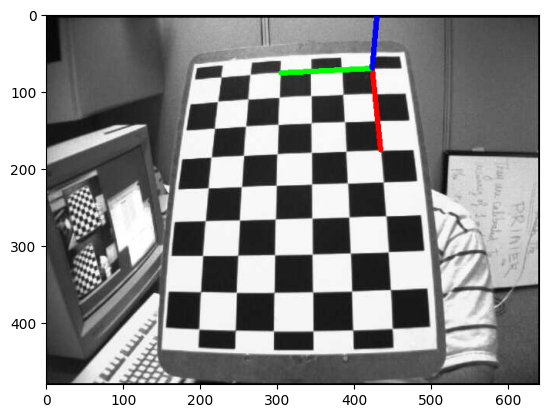

In [10]:
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Пример оси (для 3D "стрелочек"):
axis = np.float32([[3,0,0], [0,3,0], [0,0,-3]]).reshape(-1,3)

def draw(img, corners, imgpts):
    corner = tuple(map(int, corners[0].ravel()))
    img = cv.line(img, corner, tuple(map(int, imgpts[0].ravel())), (255,0,0), 5)
    img = cv.line(img, corner, tuple(map(int, imgpts[1].ravel())), (0,255,0), 5)
    img = cv.line(img, corner, tuple(map(int, imgpts[2].ravel())), (0,0,255), 5)
    return img

for fname in glob.glob('left*.jpg'):
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # ищем углы шахматной доски
    ret, corners = cv.findChessboardCorners(gray, (7,6), None)
    if ret:
        corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

        # решаем PnP
        ret, rvecs, tvecs = cv.solvePnP(objp, corners2, mtx, dist)

        # проецируем 3D точки на 2D
        imgpts, jac = cv.projectPoints(axis, rvecs, tvecs, mtx, dist)

        # рисуем линии
        img = draw(img, corners2, imgpts)

        # Покажем в Colab
        plt.imshow(img)
        # Если нужно, можно сохранять
        # cv.imwrite(fname[:6]+'.png', img)

In [11]:
def draw(img, corners, imgpts):
    imgpts = np.int32(imgpts).reshape(-1,2)
    # draw ground floor in green
    img = cv.drawContours(img, [imgpts[:4]],-1,(0,255,0),-3)
    # draw pillars in blue color
    for i,j in zip(range(4),range(4,8)):
        img = cv.line(img, tuple(imgpts[i]), tuple(imgpts[j]),(255),3)
    # draw top layer in red color
    img = cv.drawContours(img, [imgpts[4:]],-1,(0,0,255),3)
    return img

axis = np.float32([[0,0,0], [0,3,0], [3,3,0], [3,0,0],
                   [0,0,-3],[0,3,-3],[3,3,-3],[3,0,-3] ])

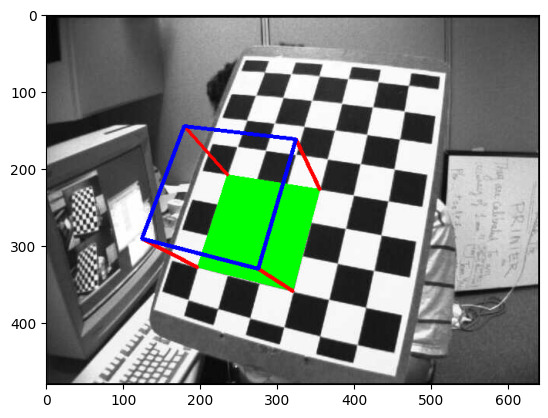

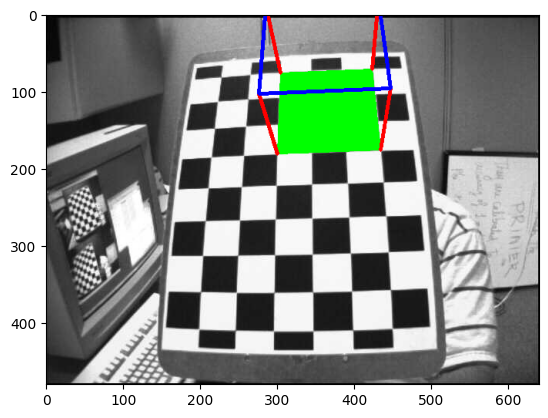

In [13]:
for fname in glob.glob('left*.jpg'):
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # ищем углы шахматной доски
    ret, corners = cv.findChessboardCorners(gray, (7,6), None)
    if ret:
        corners2 = cv.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

        # решаем PnP
        ret, rvecs, tvecs = cv.solvePnP(objp, corners2, mtx, dist)

        # проецируем 3D точки на 2D
        imgpts, jac = cv.projectPoints(axis, rvecs, tvecs, mtx, dist)

        # рисуем линии
        img = draw(img, corners2, imgpts)

        plt.imshow(img)
        plt.show()
        # Если нужно, можно сохранять
        # cv.imwrite(fname[:6]+'.png', img)